# Pruebas Estadísticas en Finanzas
## Toma Decisiones Basadas en Evidencia

*Autor: wellcome peujio jiotsop foze*

---

Este notebook te enseña cómo usar **pruebas estadísticas** para validar hipótesis financieras. Aprenderás a determinar si tus estrategias realmente funcionan o si solo fue suerte.

## Introducción: ¿Qué es una Prueba de Hipótesis?

Una **prueba de hipótesis** es un método estadístico para evaluar si los datos apoyan o rechazan una afirmación sobre una población.

### Ejemplo Financiero

**Pregunta**: ¿Los retornos de AAPL son significativamente mayores que 0%?

**Proceso**:
1. Formular hipótesis (H₀ y H₁)
2. Elegir nivel de significancia (α)
3. Calcular estadístico de prueba
4. Obtener valor p
5. Tomar decisión: Rechazar o no rechazar H₀

---

## Paso 1: Hipótesis Nula vs Hipótesis Alternativa

### Hipótesis Nula (H₀)

Es lo que **asumimos por defecto**. La afirmación "aburrida" que queremos rechazar.

**Ejemplos**:
- Los retornos son = 0%
- No hay diferencia entre dos estrategias
- La estrategia no funciona

### Hipótesis Alternativa (H₁)

Es lo que **queremos probar**. La afirmación "interesante".

**Ejemplos**:
- Los retornos son ≠ 0%
- Hay diferencia significativa entre estrategias
- La estrategia SÍ funciona

### Regla Importante

> **NUNCA se acepta H₀. Solo se rechaza o no se rechaza.**

Si p > α → No rechazamos H₀ (pero no significa que sea verdadera)

Si p < α → Rechazamos H₀ (hay evidencia de H₁)

---

## Paso 2: Valor p y Nivel de Significancia

### Nivel de Significancia (α)

Es el **umbral de decisión** que elegimos antes de hacer la prueba.

- **α = 0.05** (5%): Estándar en finanzas (95% de confianza)
- **α = 0.01** (1%): Muy conservador (99% de confianza)
- **α = 0.10** (10%): Menos conservador (90% de confianza)

### Valor p (p-value)

Es la **probabilidad de obtener nuestros datos si H₀ fuera verdadera**.

**Interpretación**:
- **p < 0.01**: Evidencia muy fuerte para rechazar H₀
- **p < 0.05**: Evidencia fuerte para rechazar H₀
- **p > 0.05**: No hay evidencia suficiente

### Regla de Decisión

$$Si\ p < \alpha \rightarrow Rechazamos\ H_0$$
$$Si\ p \geq \alpha \rightarrow No\ rechazamos\ H_0$$

---

## Paso 3: Errores Tipo I y Tipo II

Toda decisión estadística conlleva riesgo de error.

### Error Tipo I (α)

**Rechazar H₀ cuando es verdadera** (Falso Positivo)

**Ejemplo**: Creer que una estrategia funciona cuando NO funciona

**Consecuencia**: Invertir dinero en estrategia perdedora

### Error Tipo II (β)

**No rechazar H₀ cuando es falsa** (Falso Negativo)

**Ejemplo**: Creer que una estrategia NO funciona cuando SÍ funciona

**Consecuencia**: Perder oportunidad de inversión rentable

### Tabla de Decisión

| Decisión | H₀ Verdadera | H₀ Falsa |
|---|---|---|
| No rechazar H₀ | ✓ Correcto (1-α) | ✗ Error Tipo II (β) |
| Rechazar H₀ | ✗ Error Tipo I (α) | ✓ Correcto (1-β) |

**Nota**: No puedes minimizar ambos errores simultáneamente. Hay un trade-off.

---

## Preparación: Descargar Datos

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Descargar datos de AAPL (1 año)
aapl = yf.download('AAPL', period='1y', progress=False)
returns = aapl['Close'].pct_change().dropna().squeeze()

print(f'Datos descargados: {len(returns)} días de trading')
print(f'Retorno promedio diario: {returns.mean()*100:.4f}%')
print(f'Volatilidad diaria: {returns.std()*100:.4f}%')

/tmp/ipykernel_574/2854663971.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', period='1y', progress=False)


Datos descargados: 250 días de trading
Retorno promedio diario: 0.0813%
Volatilidad diaria: 2.0046%


---

# Ejemplo 1: Test t de Una Muestra

**Pregunta**: ¿Los retornos de AAPL son significativamente diferentes de 0%?

**Hipótesis**:
- H₀: μ = 0 (retorno promedio = 0%)
- H₁: μ ≠ 0 (retorno promedio ≠ 0%)

**Fórmula del estadístico t**:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

Donde:
- $\bar{x}$ = Media muestral
- $\mu_0$ = Media bajo H₀ (0 en este caso)
- $s$ = Desviación estándar
- $n$ = Tamaño de muestra

In [4]:
# Test t de una muestra
# H0: retorno promedio = 0
# H1: retorno promedio ≠ 0

t_stat, p_value = stats.ttest_1samp(returns, 0)
alpha = 0.05

print('='*60)
print('TEST T DE UNA MUESTRA')
print('='*60)
print(f'\nH0: Retorno promedio = 0%')
print(f'H1: Retorno promedio ≠ 0%')
print(f'\nEstadístico t: {t_stat:.4f}')
print(f'Valor p (bilateral): {p_value:.6f}')
print(f'Nivel de significancia (α): {alpha}')
print(f'\nRetorno promedio: {returns.mean()*100:.4f}%')
print(f'Retorno anualizado: {returns.mean()*252*100:.2f}%')

if p_value < alpha:
    print(f'\n✓ DECISIÓN: Rechazamos H0 (p = {p_value:.6f} < {alpha})')
    print('Los retornos de AAPL son SIGNIFICATIVAMENTE diferentes de 0%')
else:
    print(f'\n✗ DECISIÓN: No rechazamos H0 (p = {p_value:.6f} ≥ {alpha})')
    print('No hay evidencia suficiente de que los retornos sean diferentes de 0%')
print('='*60)

TEST T DE UNA MUESTRA

H0: Retorno promedio = 0%
H1: Retorno promedio ≠ 0%

Estadístico t: 0.6411
Valor p (bilateral): 0.522075
Nivel de significancia (α): 0.05

Retorno promedio: 0.0813%
Retorno anualizado: 20.48%

✗ DECISIÓN: No rechazamos H0 (p = 0.522075 ≥ 0.05)
No hay evidencia suficiente de que los retornos sean diferentes de 0%


---

# Ejemplo 2: Visualizar la Distribución t

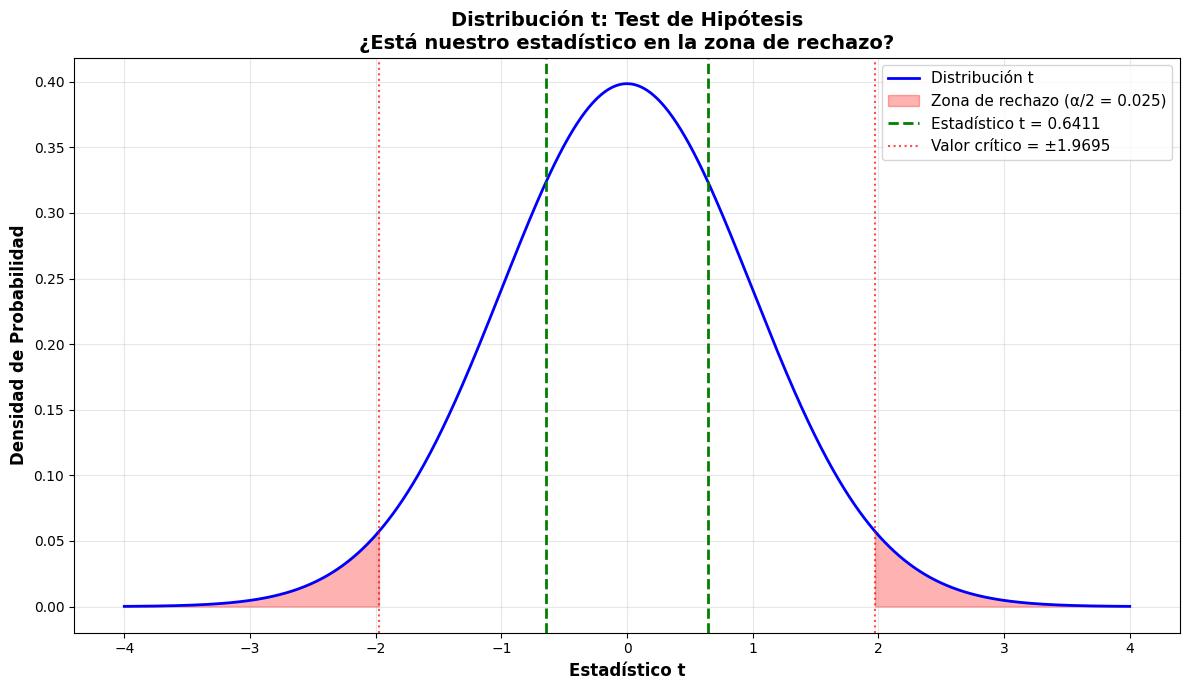


Valor crítico (bilateral): ±1.9695
Nuestro estadístico t: 0.6411
✗ El estadístico NO está en la zona de rechazo → No rechazamos H0


In [5]:
# Crear gráfico de la distribución t
fig, ax = plt.subplots(figsize=(12, 7))

# Generar distribución t teórica
df = len(returns) - 1  # grados de libertad
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

# Graficar distribución
ax.plot(x, y, 'b-', linewidth=2, label='Distribución t')

# Sombrear zonas de rechazo (bilateral)
t_critical = stats.t.ppf(1 - alpha/2, df)
x_left = x[x <= -t_critical]
x_right = x[x >= t_critical]

ax.fill_between(x_left, stats.t.pdf(x_left, df), alpha=0.3, color='red', label=f'Zona de rechazo (α/2 = {alpha/2})')
ax.fill_between(x_right, stats.t.pdf(x_right, df), alpha=0.3, color='red')

# Marcar el estadístico t calculado
ax.axvline(t_stat, color='green', linestyle='--', linewidth=2, label=f'Estadístico t = {t_stat:.4f}')
ax.axvline(-t_stat, color='green', linestyle='--', linewidth=2)

# Marcar valores críticos
ax.axvline(t_critical, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(-t_critical, color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Valor crítico = ±{t_critical:.4f}')

ax.set_xlabel('Estadístico t', fontsize=12, fontweight='bold')
ax.set_ylabel('Densidad de Probabilidad', fontsize=12, fontweight='bold')
ax.set_title('Distribución t: Test de Hipótesis\n¿Está nuestro estadístico en la zona de rechazo?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nValor crítico (bilateral): ±{t_critical:.4f}')
print(f'Nuestro estadístico t: {t_stat:.4f}')
if abs(t_stat) > t_critical:
    print('✓ El estadístico está en la zona de rechazo → Rechazamos H0')
else:
    print('✗ El estadístico NO está en la zona de rechazo → No rechazamos H0')

---

# Ejemplo 3: Test t de Dos Muestras

**Pregunta**: ¿Hay diferencia significativa entre los retornos de AAPL y MSFT?

**Hipótesis**:
- H₀: μ_AAPL = μ_MSFT (retornos iguales)
- H₁: μ_AAPL ≠ μ_MSFT (retornos diferentes)

In [8]:
# Descargar datos de MSFT
msft = yf.download('MSFT', period='1y', progress=False)
msft_returns = msft['Close'].pct_change().dropna().squeeze()

print(f'Datos descargados: {len(msft_returns)} días de trading')

# Test t de dos muestras independientes
t_stat_2, p_value_2 = stats.ttest_ind(returns, msft_returns)

print('='*60)
print('TEST T DE DOS MUESTRAS')
print('='*60)
print(f'\nH0: Retorno AAPL = Retorno MSFT')
print(f'H1: Retorno AAPL ≠ Retorno MSFT')
print(f'\nRetorno promedio AAPL: {returns.mean()*100:.4f}%')
print(f'Retorno promedio MSFT: {msft_returns.mean()*100:.4f}%')
print(f'Diferencia: {(returns.mean() - msft_returns.mean())*100:.4f}%')
print(f'\nEstadístico t: {t_stat_2:.4f}')
print(f'Valor p: {p_value_2:.6f}')
print(f'Nivel de significancia (α): {alpha}')

if p_value_2 < alpha:
    print(f'\n✓ DECISIÓN: Rechazamos H0 (p = {p_value_2:.6f} < {alpha})')
    print('Hay diferencia SIGNIFICATIVA entre AAPL y MSFT')
else:
    print(f'\n✗ DECISIÓN: No rechazamos H0 (p = {p_value_2:.6f} ≥ {alpha})')
    print('No hay diferencia significativa entre AAPL y MSFT')
print('='*60)

/tmp/ipykernel_574/4062323482.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download('MSFT', period='1y', progress=False)


Datos descargados: 250 días de trading
TEST T DE DOS MUESTRAS

H0: Retorno AAPL = Retorno MSFT
H1: Retorno AAPL ≠ Retorno MSFT

Retorno promedio AAPL: 0.0813%
Retorno promedio MSFT: 0.0207%
Diferencia: 0.0606%

Estadístico t: 0.3686
Valor p: 0.712616
Nivel de significancia (α): 0.05

✗ DECISIÓN: No rechazamos H0 (p = 0.712616 ≥ 0.05)
No hay diferencia significativa entre AAPL y MSFT


---

# Ejemplo 4: Comparación Visual de Retornos

/tmp/ipykernel_574/430784418.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['AAPL', 'MSFT'], patch_artist=True)


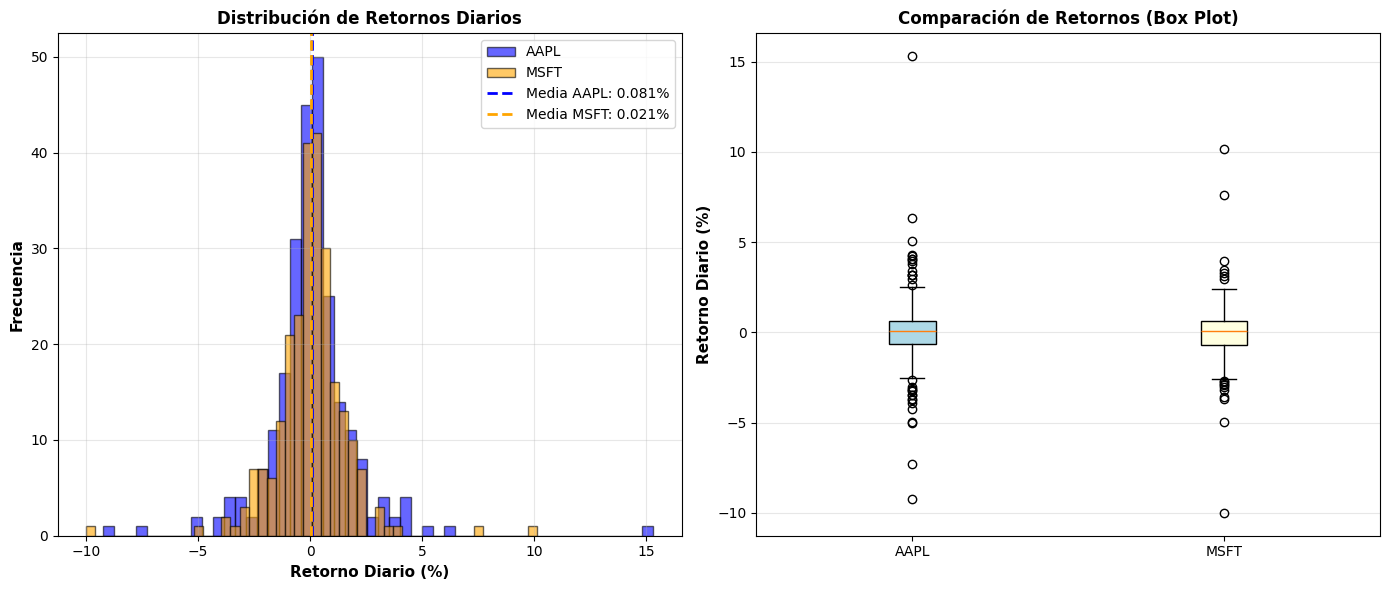


Estadísticas Descriptivas:
   Métrica     AAPL     MSFT
     Media  0.0813%  0.0207%
Desv. Est.  2.0046%  1.6527%
       Mín -9.2456% -9.9931%
       Máx 15.3288% 10.1337%
   Mediana  0.0790%  0.0618%


In [9]:
# Crear visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Histogramas
axes[0].hist(returns*100, bins=50, alpha=0.6, label='AAPL', color='blue', edgecolor='black')
axes[0].hist(msft_returns*100, bins=50, alpha=0.6, label='MSFT', color='orange', edgecolor='black')
axes[0].axvline(returns.mean()*100, color='blue', linestyle='--', linewidth=2, label=f'Media AAPL: {returns.mean()*100:.3f}%')
axes[0].axvline(msft_returns.mean()*100, color='orange', linestyle='--', linewidth=2, label=f'Media MSFT: {msft_returns.mean()*100:.3f}%')
axes[0].set_xlabel('Retorno Diario (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de Retornos Diarios', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Box plot
data_to_plot = [returns*100, msft_returns*100]
bp = axes[1].boxplot(data_to_plot, labels=['AAPL', 'MSFT'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightyellow']):
    patch.set_facecolor(color)
axes[1].set_ylabel('Retorno Diario (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Comparación de Retornos (Box Plot)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla de estadísticas
stats_table = pd.DataFrame({
    'Métrica': ['Media', 'Desv. Est.', 'Mín', 'Máx', 'Mediana'],
    'AAPL': [f'{returns.mean()*100:.4f}%', f'{returns.std()*100:.4f}%',
             f'{returns.min()*100:.4f}%', f'{returns.max()*100:.4f}%', f'{returns.median()*100:.4f}%'],
    'MSFT': [f'{msft_returns.mean()*100:.4f}%', f'{msft_returns.std()*100:.4f}%',
             f'{msft_returns.min()*100:.4f}%', f'{msft_returns.max()*100:.4f}%', f'{msft_returns.median()*100:.4f}%']
})

print('\nEstadísticas Descriptivas:')
print(stats_table.to_string(index=False))

---

# Ejemplo 5: Test de Normalidad (Shapiro-Wilk)

Muchas pruebas estadísticas asumen que los datos siguen una distribución normal. Verifiquemos esto.

**Hipótesis**:
- H₀: Los datos siguen distribución normal
- H₁: Los datos NO siguen distribución normal

In [10]:
# Test de Shapiro-Wilk
stat_aapl, p_aapl = stats.shapiro(returns)
stat_msft, p_msft = stats.shapiro(msft_returns)

print('='*60)
print('TEST DE NORMALIDAD (SHAPIRO-WILK)')
print('='*60)
print(f'\nH0: Los datos siguen distribución normal')
print(f'H1: Los datos NO siguen distribución normal')
print(f'\nAAPL:')
print(f'  Estadístico: {stat_aapl:.6f}')
print(f'  Valor p: {p_aapl:.6f}')
if p_aapl < alpha:
    print(f'  ✗ Rechazamos H0: AAPL NO es normal')
else:
    print(f'  ✓ No rechazamos H0: AAPL es aproximadamente normal')

print(f'\nMSFT:')
print(f'  Estadístico: {stat_msft:.6f}')
print(f'  Valor p: {p_msft:.6f}')
if p_msft < alpha:
    print(f'  ✗ Rechazamos H0: MSFT NO es normal')
else:
    print(f'  ✓ No rechazamos H0: MSFT es aproximadamente normal')
print('='*60)

print('\nNota: Los retornos financieros típicamente tienen colas más pesadas')
print('que la distribución normal (leptocurtosis).')

TEST DE NORMALIDAD (SHAPIRO-WILK)

H0: Los datos siguen distribución normal
H1: Los datos NO siguen distribución normal

AAPL:
  Estadístico: 0.837311
  Valor p: 0.000000
  ✗ Rechazamos H0: AAPL NO es normal

MSFT:
  Estadístico: 0.864661
  Valor p: 0.000000
  ✗ Rechazamos H0: MSFT NO es normal

Nota: Los retornos financieros típicamente tienen colas más pesadas
que la distribución normal (leptocurtosis).


---

# Ejemplo 6: Q-Q Plot (Visualizar Normalidad)

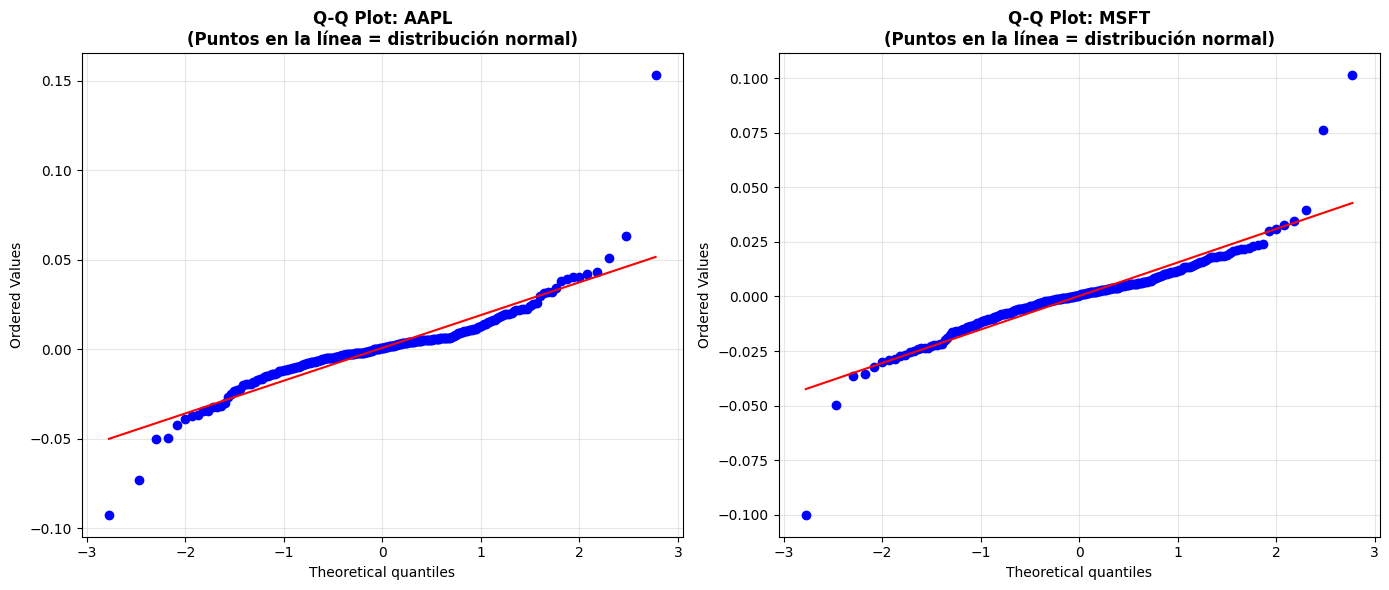

Interpretación:
- Si los puntos están cerca de la línea roja: datos son aproximadamente normales
- Si los puntos se desvían en las colas: datos tienen colas más pesadas (leptocurtosis)


In [11]:
# Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AAPL
stats.probplot(returns, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: AAPL\n(Puntos en la línea = distribución normal)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# MSFT
stats.probplot(msft_returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: MSFT\n(Puntos en la línea = distribución normal)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Interpretación:')
print('- Si los puntos están cerca de la línea roja: datos son aproximadamente normales')
print('- Si los puntos se desvían en las colas: datos tienen colas más pesadas (leptocurtosis)')

---

# Resumen: Conceptos Clave

## 1. Hipótesis Nula vs Alternativa

- **H₀**: Asunción por defecto (lo que queremos rechazar)
- **H₁**: Lo que queremos probar
- **Regla**: Nunca se acepta H₀, solo se rechaza o no se rechaza

## 2. Valor p y Nivel de Significancia

- **α = 0.05**: Estándar en finanzas (95% confianza)
- **p-value**: Probabilidad de los datos si H₀ fuera verdadera
- **Decisión**: Si p < α → Rechazamos H₀

## 3. Errores Tipo I y II

| Error | Descripción | Consecuencia |
|---|---|---|
| Tipo I (α) | Rechazar H₀ verdadera | Invertir en estrategia perdedora |
| Tipo II (β) | No rechazar H₀ falsa | Perder oportunidad rentable |

## 4. Pruebas Comunes en Finanzas

- **Test t de una muestra**: ¿El retorno es diferente de 0%?
- **Test t de dos muestras**: ¿Hay diferencia entre dos activos?
- **Test de normalidad**: ¿Los datos son normales?
- **Test de correlación**: ¿Hay correlación significativa?

## 5. Interpretación Correcta

- p < 0.01: Evidencia muy fuerte
- p < 0.05: Evidencia fuerte
- p > 0.05: No hay evidencia suficiente

---

## Conclusión

Las **pruebas estadísticas** te permiten:

1. **Validar hipótesis**: Determinar si tus estrategias realmente funcionan
2. **Tomar decisiones basadas en evidencia**: No confiar en intuición
3. **Cuantificar riesgo**: Entender el Error Tipo I y II
4. **Evitar falsos positivos**: No invertir en estrategias que solo tuvieron suerte